<a href="https://colab.research.google.com/github/Shraddha6211/Machine-Learning-Extra-Class/blob/main/ANN_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
from google.colab import files
files.upload()

Saving car_purchasing.csv to car_purchasing (4).csv


{'car_purchasing (4).csv': b'customer name,JobTitle,customer e-mail,country,gender,age,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits,credit card debt,net worth,car purchase amount\r\nMartina Avila,GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY,cubilia.Curae.Phasellus@quisaccumsanconvallis.edu,Bulgaria,0,42,167411.18,0,400184.25,,567595.43,567595.43,11609.38091,238961.2505,35321.45877\r\nHarlan Barnes,CAPTAIN III (POLICE DEPARTMENT),eu.dolor@diam.co.uk,Belize,0,41,155966.02,245131.88,137811.38,,538909.28,538909.28,9572.957136,530973.9078,45115.52566\r\nNaomi Rodriquez,CAPTAIN III (POLICE DEPARTMENT),vulputate.mauris.sagittis@ametconsectetueradipiscing.co.uk,Algeria,1,43,212739.13,106088.18,16452.6,,335279.91,335279.91,11160.35506,638467.1773,42925.70921\r\nJade Cunningham,WIRE ROPE CABLE MAINTENANCE MECHANIC,malesuada@dignissim.com,Cook Islands,1,58,77916,56120.71,198306.9,,332343.61,332343.61,14426.16485,548599.0524,67422.36313\r\nCedric Leach,"DEPUTY CHIEF OF DEPARTM

In [12]:
import pandas as pd
import numpy as np

# Load Dataset
df = pd.read_csv('car_purchasing.csv', encoding= 'latin1')
df.head(3)

,customer name,JobTitle,customer e-mail,country,gender,age,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits,credit card debt,net worth,car purchase amount
0,Martina Avila,GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY,cubilia.Curae.Phasellus@quisaccumsanconvallis.edu,Bulgaria,0,42,167411.18,0.00,400184.25,NaN,567595.43,567595.43,11609.380910,238961.2505,35321.45877
1,Harlan Barnes,CAPTAIN III (POLICE DEPARTMENT),eu.dolor@diam.co.uk,Belize,0,41,155966.02,245131.88,137811.38,NaN,538909.28,538909.28,9572.957136,530973.9078,45115.52566
2,Naomi Rodriquez,CAPTAIN III (POLICE DEPARTMENT),vulputate.mauris.sagittis@ametconsectetueradip...,Algeria,1,43,212739.13,106088.18,16452.60,NaN,335279.91,335279.91,11160.355060,638467.1773,42925.70921


In [13]:
df= df.drop([
    'customer name',
    'customer e-mail',
    'country',
    'Benefits',
    'JobTitle'

], axis =1)
df.sample(3)

,gender,age,BasePay,OvertimePay,OtherPay,TotalPay,TotalPayBenefits,credit card debt,net worth,car purchase amount
113,0,58,188708.00,0.00,31572.3,220280.30,220280.30,11211.72016,565932.1861,51941.67560
205,1,50,205609.58,0.00,0.0,205609.58,205609.58,11302.88277,490444.4111,48518.90163
235,1,43,110638.66,65587.13,26005.7,202231.49,202231.49,14709.65824,568947.7487,50702.18103


In [14]:
df.shape

(500, 10)

In [15]:
df.isnull().sum()

,0
gender,0
age,0
BasePay,0
OvertimePay,0
OtherPay,0
TotalPay,0
TotalPayBenefits,0
credit card debt,0
net worth,0
car purchase amount,0


In [16]:
X = df.drop('car purchase amount', axis =1)
y = df['car purchase amount']
X.head(3)

,gender,age,BasePay,OvertimePay,OtherPay,TotalPay,TotalPayBenefits,credit card debt,net worth
0,0,42,167411.18,0.00,400184.25,567595.43,567595.43,11609.380910,238961.2505
1,0,41,155966.02,245131.88,137811.38,538909.28,538909.28,9572.957136,530973.9078
2,1,43,212739.13,106088.18,16452.60,335279.91,335279.91,11160.355060,638467.1773


In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape

(400, 9)

In [19]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
# Regression
from tensorflow import keras
from tensorflow.keras import layers

reg_model = keras.Sequential([
    layers.Dense(64, activation = 'relu', input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation = 'relu'),
    layers.Dense(1)   # REgression output
])

reg_model.compile(optimizer = 'adam', loss = 'mean_squared_error', metrics =['mae'])
reg_model.fit(X_train, y_train, epochs = 100, batch_size = 32, validation_split = 0.2, verbose =1)


Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 2076184832.0000 - mae: 44200.9453 - val_loss: 1938686592.0000 - val_mae: 42925.4805
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2076135040.0000 - mae: 44200.3711 - val_loss: 1938632448.0000 - val_mae: 42924.8555
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2076083200.0000 - mae: 44199.7852 - val_loss: 1938574336.0000 - val_mae: 42924.1797
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2076025216.0000 - mae: 44199.1328 - val_loss: 1938507776.0000 - val_mae: 42923.4102
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2075957632.0000 - mae: 44198.3672 - val_loss: 1938428544.0000 - val_mae: 42922.4922
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2075875328.0000 - mae: 44197.4297 - val_loss: 1938331008.0000 - val_mae: 42921.3672
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2075775744.0000 - mae: 44196.2891 - val_loss: 1938211584.0000 - val_mae: 42919.9922
Epoch 8/10

In [23]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
y_pred = reg_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
print(f'Mean Absolute Error: {mae}')


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Mean Squared Error: 1411984271.3974078
Mean Absolute Error: 36410.54759718046


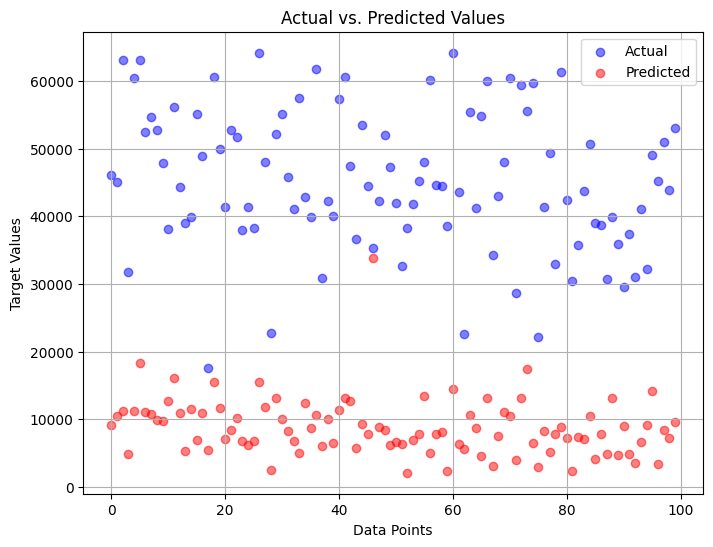

In [25]:
import matplotlib.pyplot as plt

# Convert tensors to numpy if using Tensorflow
y_test_np = y_test.numpy()  if hasattr(y_test, 'numpy') else y_test
y_pred_np = y_pred.numpy()  if hasattr(y_pred, 'numpy') else y_pred

# Scatter plot with different colors
plt.figure(figsize =(8,6))

# Plot actual values (y_test) as blue dots
plt.scatter(np.arange(len(y_test_np)), y_test_np, color = 'blue', label = 'Actual', alpha = 0.5)

# Plot predicted values (y_pred) as red dots
plt.scatter(np.arange(len(y_pred_np)), y_pred_np, color = 'red', label = 'Predicted', alpha = 0.5)

plt.xlabel('Data Points')
plt.ylabel('Target Values')
plt.title('Actual vs. Predicted Values')
plt.legend()
plt.grid(True)
plt.show()

In [27]:
new_customer = np.array([[
    1,
    45,
    50000,
    2000,
    1500,
    3000,
    56500,
    59500,
    8000,

]])

# Scale using trained scaler
new_customer_scaled = scaler.transform(new_customer)

# Predict
predicted_amount = reg_model.predict(new_customer_scaled)

print("Predicted Car Purchase Amount:", predicted_amount[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
Predicted Car Purchase Amount: 30535.121
